In [1]:
# 1. Importar librerías necesarias
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 2. Descargar datos históricos de IBM y Walmart (últimos 5 años, frecuencia diaria)
tickers = 'IBM WMT'
datos = yf.download(tickers=tickers, period='5y', interval='1d', rounding=True)

# 3. Extraer solo la columna de precios de cierre ('Close')
precios = datos['Close']

# 4. Eliminar valores nulos (días sin operaciones en bolsa)
precios = precios.dropna()

# 5. Mostrar los primeros registros para validar la extracción
precios.head()

[*********************100%***********************]  2 of 2 completed


Ticker,IBM,WMT
Date,,
2021-04-19,104.26,43.60
2021-04-20,108.21,43.94
2021-04-21,112.43,44.07
2021-04-22,110.65,43.59
2021-04-23,111.55,43.66


Correlación entre IBM y Walmart: 0.1782


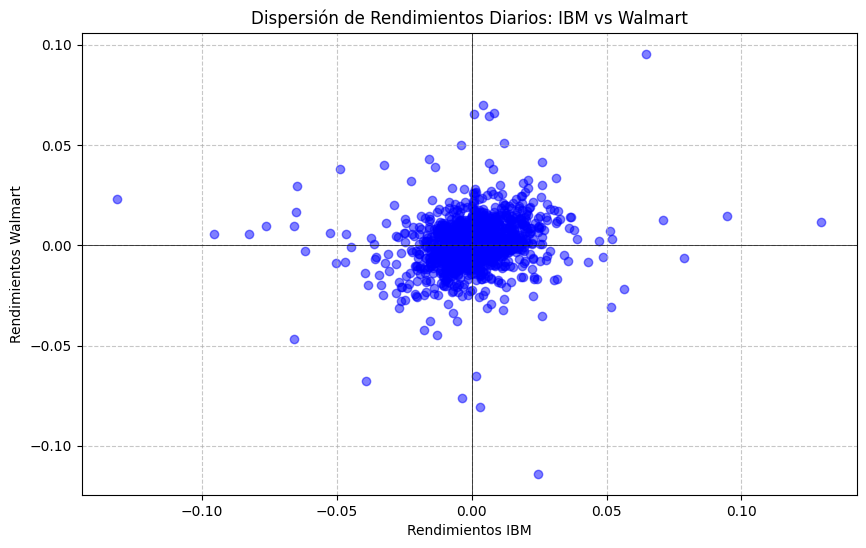

In [2]:
# 1. Calcular los rendimientos diarios (porcentaje de cambio)
rendimientos = precios.pct_change().dropna()

# 2. Calcular el índice de correlación entre IBM y Walmart
correlacion = rendimientos['IBM'].corr(rendimientos['WMT'])
print(f"Correlación entre IBM y Walmart: {correlacion:.4f}")

# 3. Graficar la dispersión para ver la relación visualmente
plt.figure(figsize=(10, 6))
plt.scatter(rendimientos['IBM'], rendimientos['WMT'], alpha=0.5, color='blue')
plt.title('Dispersión de Rendimientos Diarios: IBM vs Walmart')
plt.xlabel('Rendimientos IBM')
plt.ylabel('Rendimientos Walmart')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

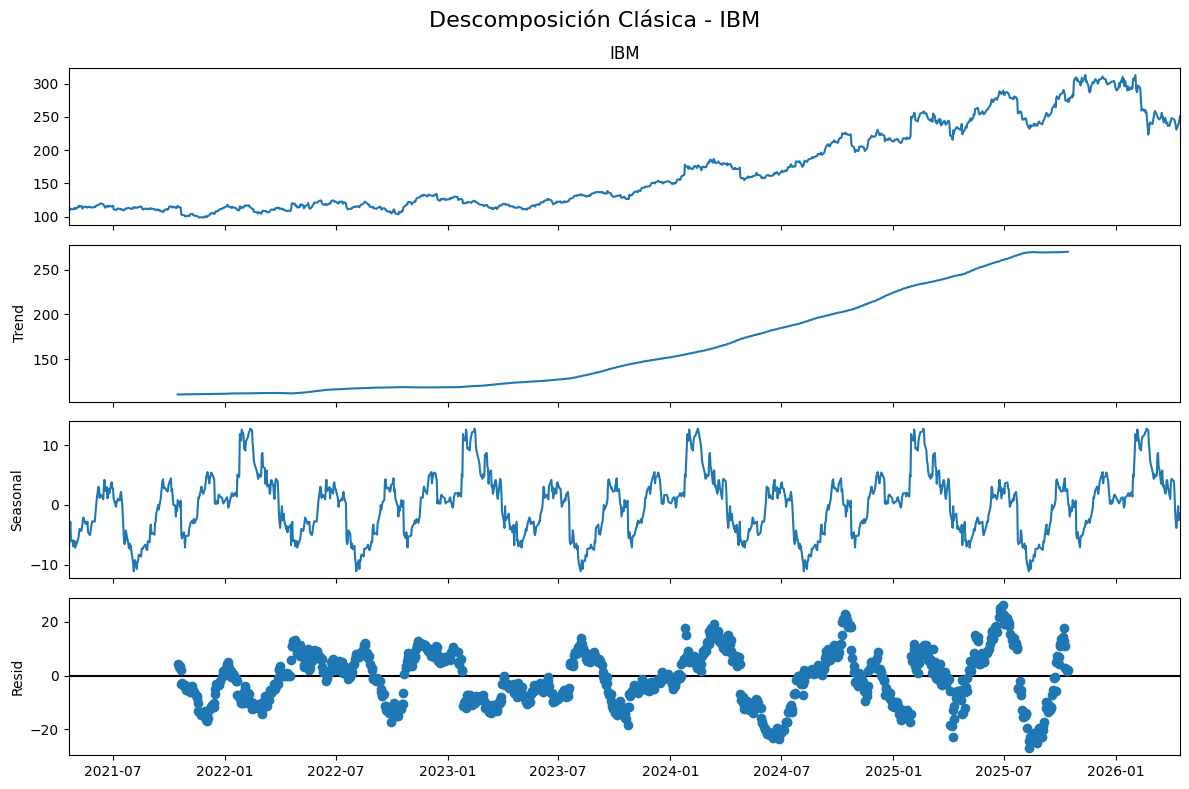

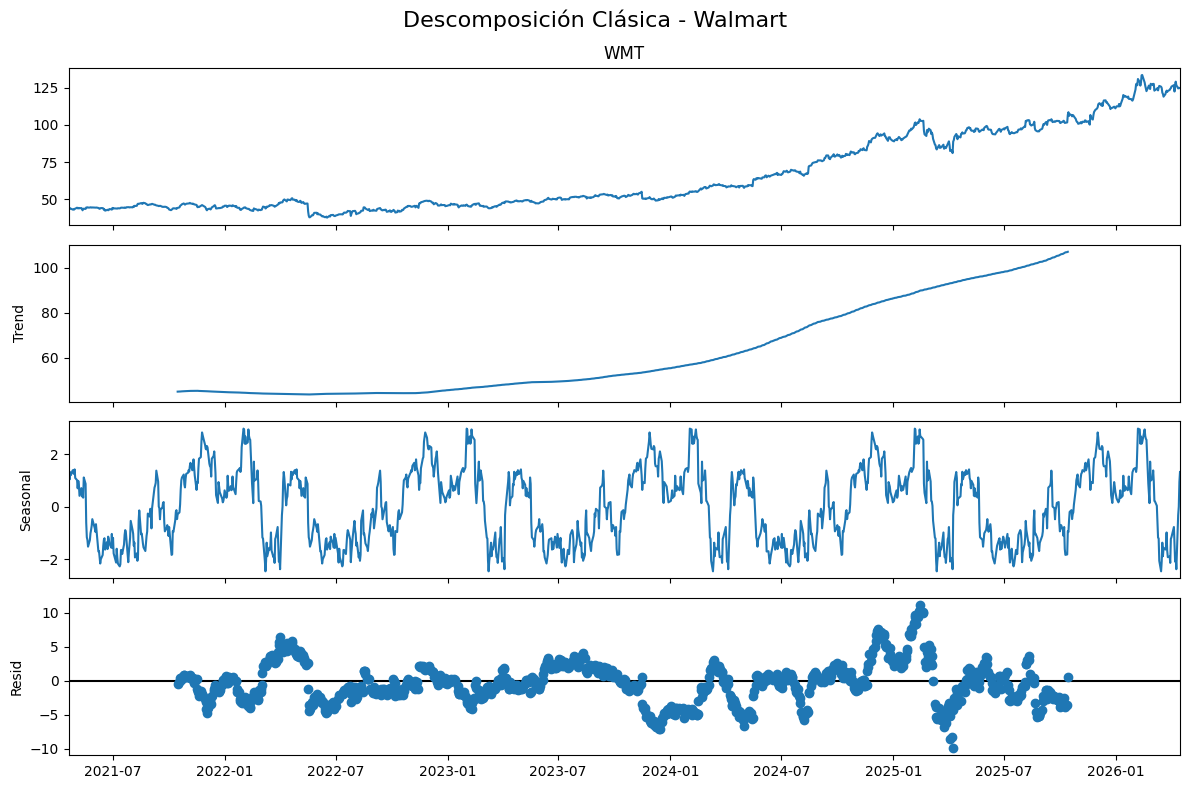

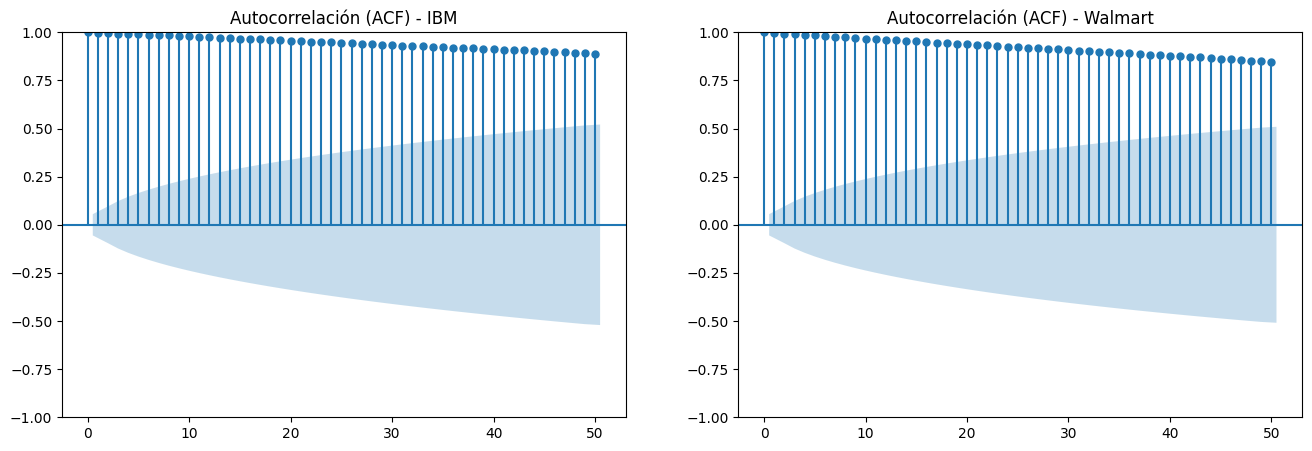

In [3]:
# 1. Importar herramientas de descomposición y autocorrelación
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

# 2. Descomponer series asumiendo 252 días de operación anual
descomp_ibm = seasonal_decompose(precios['IBM'], model='additive', period=252)
descomp_wmt = seasonal_decompose(precios['WMT'], model='additive', period=252)

# 3. Graficar la descomposición de IBM
fig_ibm = descomp_ibm.plot()
fig_ibm.set_size_inches(12, 8)
plt.suptitle('Descomposición Clásica - IBM', fontsize=16)
plt.tight_layout()
plt.show()

# 4. Graficar la descomposición de Walmart
fig_wmt = descomp_wmt.plot()
fig_wmt.set_size_inches(12, 8)
plt.suptitle('Descomposición Clásica - Walmart', fontsize=16)
plt.tight_layout()
plt.show()

# 5. Graficar Correlogramas (ACF) para medir la memoria de los datos
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(precios['IBM'], ax=ax[0], lags=50, title='Autocorrelación (ACF) - IBM')
plot_acf(precios['WMT'], ax=ax[1], lags=50, title='Autocorrelación (ACF) - Walmart')
plt.show()

In [4]:
# 1. Importar la herramienta estadística
from statsmodels.tsa.stattools import adfuller

# 2. Ejecutar la prueba para IBM
result_ibm = adfuller(precios['IBM'])
print(f"Valor p (p-value) de Dickey-Fuller para IBM: {result_ibm[1]:.4f}")

# 3. Ejecutar la prueba para Walmart
result_wmt = adfuller(precios['WMT'])
print(f"Valor p (p-value) de Dickey-Fuller para Walmart: {result_wmt[1]:.4f}")

Valor p (p-value) de Dickey-Fuller para IBM: 0.8650
Valor p (p-value) de Dickey-Fuller para Walmart: 0.9957


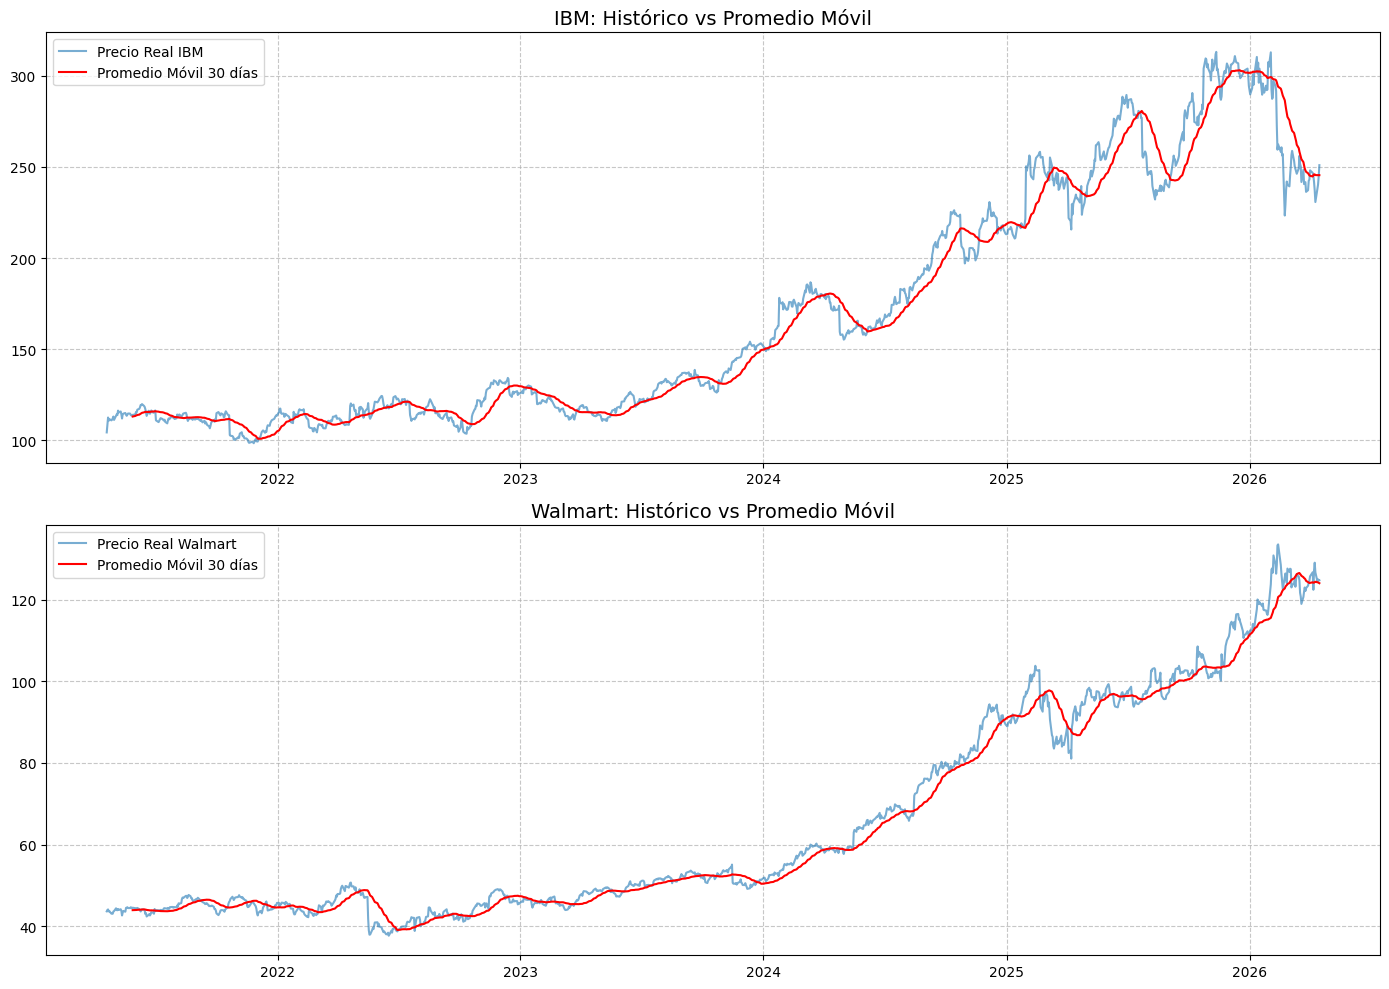

Pronóstico para el siguiente día (IBM): $245.52
Pronóstico para el siguiente día (Walmart): $124.10


In [5]:
# 1. Calcular promedios móviles de 30 días para suavizar la tendencia
ma30_ibm = precios['IBM'].rolling(window=30).mean()
ma30_wmt = precios['WMT'].rolling(window=30).mean()

# 2. Generar el análisis gráfico comparativo
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

# Gráfica para IBM
ax[0].plot(precios.index, precios['IBM'], label='Precio Real IBM', alpha=0.6)
ax[0].plot(precios.index, ma30_ibm, label='Promedio Móvil 30 días', color='red')
ax[0].set_title('IBM: Histórico vs Promedio Móvil', fontsize=14)
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.7)

# Gráfica para Walmart
ax[1].plot(precios.index, precios['WMT'], label='Precio Real Walmart', alpha=0.6)
ax[1].plot(precios.index, ma30_wmt, label='Promedio Móvil 30 días', color='red')
ax[1].set_title('Walmart: Histórico vs Promedio Móvil', fontsize=14)
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 3. Pronosticar el precio del siguiente día (promedio de los últimos 30 días)
pronostico_ibm = precios['IBM'].tail(30).mean()
pronostico_wmt = precios['WMT'].tail(30).mean()

print(f"Pronóstico para el siguiente día (IBM): ${pronostico_ibm:.2f}")
print(f"Pronóstico para el siguiente día (Walmart): ${pronostico_wmt:.2f}")